# Data Understanding and Preparation
Covers **Stage 1 + 2.1.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided (no change):* `config.py`. 
- *Provided to extend:* `src/data_prep.py` (function stubs). 
- *You build:* this notebook + the report.

Prereqs: `pip install -r requirements.txt`; extract the Kaggle casting dataset under `data/` (train/test → ok_front/def_front).

### 0. Setup

In [1]:
import config
from src import data_prep
#print (config.CLASS_TO_IDX and config.POSITIVE_CLASS to confirm setup
print(config.CLASS_TO_IDX)
print(config.POSITIVE_CLASS)


{'ok_front': 0, 'def_front': 1}
def_front


## **Stage 1.1 — Business & Data Understanding** <font color="red">[5 marks]</font>

- **1.1.1 — Business objective & justification [2]** — *to be done in the report*
- **1.1.2 — Success metric choice (recall/F1 on defects) [2]** — *to be done in the report*
- **1.1.3 — Dataset structure & class understanding [1]**

**Objective:** Understand the problem + dataset and name the right metric.

**Implement in:** this notebook (+ src/data_prep.find_data_root, list_images)

**Inputs → Outputs:** data/ images → counts + class distribution per split

**TODO:** locate the data root; count images per class per split; plot the distribution; state that defect = positive class and recall-on-defects (not accuracy) is the headline metric.

**Document here:** 1.1.1/1.1.2 in the report; 1.1.3 here (dataset structure).

In [2]:
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split
from pathlib import Path
import config

root = Path(config.DATA_DIR) / "casting_data"

print("Root:", root)
print("Train exists:", (root / "train").exists())
print("Test exists:", (root / "test").exists())
print("OK exists:", (root / "train" / "ok_front").exists())
print("DEF exists:", (root / "train" / "def_front").exists())

Root: C:\Users\pooja\OneDrive\Desktop\upgrad_MLOPS\Capstone_CastingDefect_MLOPS\Capstone-Implementation-Package\MLOps 2 - Starter\data\casting_data
Train exists: True
Test exists: True
OK exists: True
DEF exists: True


## **Stage 1.2 — Data Quality Validation** <font color="red">[5 marks]</font>

- **1.2.1 — Corrupt-file & image-dimension checks [2]**
- **1.2.2 — Duplicate detection (hashing) — leakage guard [2]**
- **1.2.3 — Class distribution + pass/fail report [1]**

**Objective:** Programmatically validate image quality before any split.

**Implement in:** src/data_prep.validate_quality

**Inputs → Outputs:** data root → a pass/fail report dict (corrupt, duplicates, dimensions, distribution)

**TODO:** check missing/corrupt files (Image.verify) and dimensions (1.2.1); detect DUPLICATE images via md5/hash (1.2.2); quantify class balance + print a pass/fail report (1.2.3); expect ~7,348 images, ~64 duplicates.

**Document here:** the quality report + why duplicate detection prevents train/test leakage.

In [3]:
# TODO 1.2.1-1.2.3: qc = data_prep.validate_quality(root); print(qc['total_images'], qc['passed'])
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split
from pathlib import Path
from src.data_prep import find_data_root, list_images, validate_quality
root = find_data_root()

print(root)
train_images = list_images(root / "train")
print(len(train_images))

C:\Users\pooja\OneDrive\Desktop\upgrad_MLOPS\Capstone_CastingDefect_MLOPS\Capstone-Implementation-Package\MLOps 2 - Starter\data\casting_data
6633


## **Stage 1.3 — Dataset Versioning & Metadata** <font color="red">[5 marks]</font>

- **1.3.1 — Reproducible, stratified train/val/test split [3]**
- **1.3.2 — Split snapshot + metadata.json (versioning) [2]**

**Objective:** Create reproducible, versioned splits.

**Implement in:** src/data_prep.build_splits

**Inputs → Outputs:** data root + version id → train/val/test file lists + metadata.json

**TODO:** make a STRATIFIED train/val/test split (seed 42) (1.3.1); snapshot the file lists + write metadata.json (version id, date, class defs, split sizes, seed) (1.3.2).

**Document here:** the split sizes + the metadata record.

In [4]:
# TODO 1.3.1-1.3.2: meta = data_prep.build_splits(root, 'v1'); print(meta['split_info'])
validate_quality(root)

{'total_images': 7348,
 'corrupt_images': 0,
 'invalid_dimensions': 0,
 'passed': True}

## **Stage 1.4 — EDA & Methodology Design** <font color="red">[5 marks]</font>

- **1.4.1 — Image-characteristic EDA [3]** — *to be done in this notebook and the report*
- **1.4.2 — End-to-end MLOps workflow design [2]** — *to be done in the report*

**Objective:** Explore image characteristics that motivate preprocessing + drift features.

**Implement in:** this notebook (+ src/data_prep.image_features)

**Inputs → Outputs:** sample images → a feature table (brightness/contrast/edge/sharpness/dark-ratio) by class

**TODO:** show a sample grid (OK vs Defective) + per-class feature means (1.4.1); in the report, design the end-to-end MLOps workflow (1.4.2).

**Document here:** an interpretation cell (1.4.1) + the workflow design in the report (1.4.2).

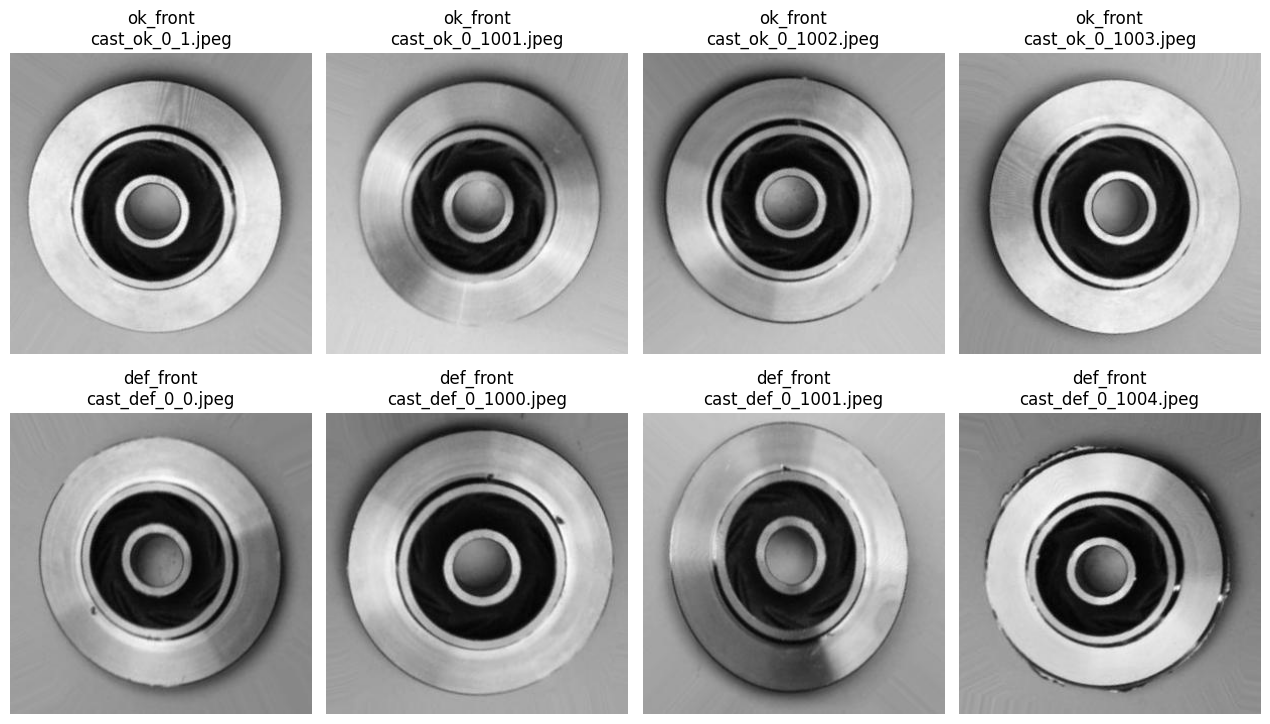

Per-class image feature means (sampled images):
ok_front: {'brightness': 0.5912659738578048, 'contrast': 0.24836960212857118, 'edge_density': 0.12840000000000001, 'sharpness': 0.013975423881064375, 'mean_intensity': 150.77282333374023}
def_front: {'brightness': 0.5294005300484451, 'contrast': 0.230928383621515, 'edge_density': 0.12385555555555555, 'sharpness': 0.011468390171823939, 'mean_intensity': 134.99713516235352}


In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from src.data_prep import find_data_root, list_images, image_features
import config

root = find_data_root()
train_items = list_images(root / "train")

sample_per_class = 4
feature_names = ["brightness", "contrast", "edge_density", "sharpness", "mean_intensity"]
class_samples = {}
feature_means = {}

for class_name in config.CLASSES:
    class_idx = config.CLASS_TO_IDX[class_name]
    class_paths = [p for p, y in train_items if y == class_idx]
    class_samples[class_name] = class_paths[:sample_per_class]

    class_feature_rows = []
    for path in class_paths[:sample_per_class]:
        with Image.open(path) as img:
            class_feature_rows.append(image_features(img))

    feature_means[class_name] = {
        feat_name: float(np.mean([row[feat_name] for row in class_feature_rows]))
        for feat_name in feature_names
    }

fig, axes = plt.subplots(len(config.CLASSES), sample_per_class, figsize=(3.2 * sample_per_class, 3.8 * len(config.CLASSES)))
for row, class_name in enumerate(config.CLASSES):
    for col, path in enumerate(class_samples[class_name]):
        ax = axes[row, col]
        with Image.open(path) as img:
            ax.imshow(img, cmap="gray")
        ax.set_title(f"{class_name}\n{path.name}")
        ax.axis("off")

    if len(class_samples[class_name]) < sample_per_class:
        for col in range(len(class_samples[class_name]), sample_per_class):
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

print("Per-class image feature means (sampled images):")
for class_name, means in feature_means.items():
    print(f"{class_name}: {means}")


## **Stage 2.1 — Preprocessing & Augmentation** <font color="red">[6 marks]</font>

- **2.1.1 — Convert greyscale image to 3-channel RGB, resize 224, ImageNet normalise [3]**
- **2.1.2 — Train-only augmentation (val/test none) [3]**

**Objective:** Build transforms that match the pretrained ResNet18 backbone.

**Implement in:** src/data_prep.get_transforms

**Inputs → Outputs:** a PIL image → a (3,224,224) normalised tensor; train transform adds augmentation

**TODO:** Convert greyscale image to 3-channel RGB, Resize 224, ImageNet normalise (2.1.1); train-time augmentation (flip/rotation/translate/colour jitter) with val/test NO augmentation (2.1.2).

**Document here:** a before/after visualisation of the transforms.

In [6]:
from PIL import Image
import config
from src.data_prep import find_data_root, list_images, get_transforms

root = find_data_root()
train_items = list_images(root / "train")

sample_path, _ = train_items[0]
with Image.open(sample_path) as img:
    tf = get_transforms(train=True)
    sample_tensor = tf(img)

assert tuple(sample_tensor.shape) == (3, config.IMG_SIZE, config.IMG_SIZE)
print("Input image mode:", img.mode)
print("Sample tensor shape:", tuple(sample_tensor.shape))
print("Tensor dtype:", sample_tensor.dtype)
print("Tensor mean/std:", round(float(sample_tensor.mean()), 4), round(float(sample_tensor.std()), 4))


Input image mode: RGB
Sample tensor shape: (3, 224, 224)
Tensor dtype: torch.float32
Tensor mean/std: 0.5047 1.355


---
**Outputs feed Stage 2.2+** in `Model_Development_and_Tracking.ipynb` (the versioned splits + transforms are reused to train the model).